# ImageNet100

In [1]:
import shap
import pandas as pd
import numpy as np

from pathlib import Path
from xgboost import XGBRegressor

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [3]:
DATASET_NAME = "imagenet-100"
METRICS = ["test_MulticlassAccuracy", "test_MulticlassF1Score", "test_MulticlassPrecision", "test_MulticlassRecall"]
MAIN_METRIC = "test_MulticlassAccuracy"

In [4]:
RESULTS_PATH = Path(".").resolve()

## Default Projector

In [5]:
DEFAULT_EVAL_RESULTS_PATH = RESULTS_PATH.joinpath(DATASET_NAME, "default", f"rbfn-ssl-projector-default-eval_{DATASET_NAME}.csv")
print(DEFAULT_EVAL_RESULTS_PATH)
DEFAULT_RANGES = [
    "architecture",
    "projection_head_num_layers"
]

/cluster/user/aschlieb/promotion/code/rbfn-ssl-projector/results/imagenet-100/default/rbfn-ssl-projector-default-eval_imagenet-100.csv


In [6]:
df_default = pd.read_csv(DEFAULT_EVAL_RESULTS_PATH)
df_default = df_default[["projection_head_type"] + DEFAULT_RANGES + METRICS]

### By Architecture

#### SimCLR

In [7]:
df_default_simclr = df_default[df_default["architecture"] == "simclr"]
df_default_simclr = df_default_simclr.sort_values(by=MAIN_METRIC, ascending=False)
df_default_simclr

,projection_head_type,architecture,projection_head_num_layers,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall
6,default,simclr,4,0.883743,0.883998,0.888626,0.883743
7,default,simclr,3,0.881572,0.881581,0.886465,0.881572
8,default,simclr,2,0.876641,0.877157,0.882367,0.876641


#### SimSiam

In [8]:
df_default_simsiam = df_default[df_default["architecture"] == "simsiam"]
df_default_simsiam = df_default_simsiam.sort_values(by=MAIN_METRIC, ascending=False)
df_default_simsiam

,projection_head_type,architecture,projection_head_num_layers,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall
5,default,simsiam,2,0.920327,0.92083,0.925832,0.920327


#### MoCo

In [9]:
df_default_moco = df_default[df_default["architecture"] == "moco"]
df_default_moco = df_default_moco.sort_values(by=MAIN_METRIC, ascending=False)
df_default_moco

,projection_head_type,architecture,projection_head_num_layers,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall
2,default,moco,4,0.919822,0.920365,0.924260,0.919822
3,default,moco,3,0.916908,0.917451,0.921409,0.916908
4,default,moco,2,0.915585,0.916136,0.920038,0.915585


#### BYOL

In [10]:
df_default_byol = df_default[df_default["architecture"] == "byol"]
df_default_byol = df_default_byol.sort_values(by=MAIN_METRIC, ascending=False)
df_default_byol

,projection_head_type,architecture,projection_head_num_layers,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall
1,default,byol,2,0.889295,0.884485,0.895701,0.889295


#### SwAV

In [11]:
df_default_swav = df_default[df_default["architecture"] == "swav"]
df_default_swav = df_default_swav.sort_values(by=MAIN_METRIC, ascending=False)
df_default_swav

,projection_head_type,architecture,projection_head_num_layers,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall
0,default,swav,2,0.876979,0.875282,0.885032,0.876979


## RBFN Projector

In [12]:
RBFN_EVAL_RESULTS_PATH = RESULTS_PATH.joinpath(DATASET_NAME, "rbfn", f"rbfn-ssl-projector-rbfn-eval_{DATASET_NAME}.csv")
print(RBFN_EVAL_RESULTS_PATH)

RBFN_RANGES = [
    "architecture",
    "projection_head_num_layers",
    "rbfn_projection_head_num_kernels",
    "rbfn_projection_head_radial_function",
    "rbfn_projection_head_normalize"
]

/cluster/user/aschlieb/promotion/code/rbfn-ssl-projector/results/imagenet-100/rbfn/rbfn-ssl-projector-rbfn-eval_imagenet-100.csv


### By Architecture

In [13]:
df_rbfn = pd.read_csv(RBFN_EVAL_RESULTS_PATH)
df_rbfn = df_rbfn[["projection_head_type"] + RBFN_RANGES + METRICS]

#### SimCLR

In [14]:
df_rbfn_simclr = df_rbfn[df_rbfn["architecture"] == "simclr"]
df_rbfn_simclr = df_rbfn_simclr.sort_values(by=MAIN_METRIC, ascending=False)
df_rbfn_simclr

,projection_head_type,architecture,projection_head_num_layers,rbfn_projection_head_num_kernels,rbfn_projection_head_radial_function,rbfn_projection_head_normalize,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall
144,rbfn,simclr,4,128,tps,False,0.921659,0.918458,0.929467,0.921659
151,rbfn,simclr,4,128,gaussian,True,0.921659,0.918458,0.929467,0.921659
150,rbfn,simclr,4,128,gaussian,False,0.921659,0.918458,0.929467,0.921659
167,rbfn,simclr,4,512,gaussian,True,0.921659,0.918458,0.929467,0.921659
160,rbfn,simclr,4,512,tps,False,0.921659,0.918458,0.929467,0.921659
158,rbfn,simclr,4,256,gaussian,False,0.921659,0.918458,0.929467,0.921659
159,rbfn,simclr,4,256,gaussian,True,0.921659,0.918458,0.929467,0.921659
152,rbfn,simclr,4,256,tps,False,0.921659,0.918458,0.929467,0.921659
206,rbfn,simclr,2,256,gaussian,False,0.921659,0.918458,0.929467,0.921659
207,rbfn,simclr,2,256,gaussian,True,0.921659,0.918458,0.929467,0.921659


#### SimSiam

In [15]:
df_rbfn_simsiam = df_rbfn[df_rbfn["architecture"] == "simsiam"]
df_rbfn_simsiam = df_rbfn_simsiam.sort_values(by=MAIN_METRIC, ascending=False)
df_rbfn_simsiam

,projection_head_type,architecture,projection_head_num_layers,rbfn_projection_head_num_kernels,rbfn_projection_head_radial_function,rbfn_projection_head_normalize,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall
122,rbfn,simsiam,2,128,multiquadric,False,0.921792,0.918584,0.929613,0.921792
130,rbfn,simsiam,2,256,multiquadric,False,0.921792,0.918584,0.929613,0.921792
128,rbfn,simsiam,2,256,tps,False,0.921626,0.918470,0.929579,0.921626
120,rbfn,simsiam,2,128,tps,False,0.921600,0.918401,0.929393,0.921600
138,rbfn,simsiam,2,512,multiquadric,False,0.921588,0.918391,0.929461,0.921588
126,rbfn,simsiam,2,128,gaussian,False,0.921400,0.918170,0.929051,0.921400
121,rbfn,simsiam,2,128,tps,True,0.921400,0.918164,0.929047,0.921400
127,rbfn,simsiam,2,128,gaussian,True,0.921400,0.918170,0.929051,0.921400
143,rbfn,simsiam,2,512,gaussian,True,0.921400,0.918170,0.929051,0.921400
141,rbfn,simsiam,2,512,inverse_multiquadric,True,0.921400,0.918170,0.929051,0.921400


#### MoCo

In [16]:
df_rbfn_moco = df_rbfn[df_rbfn["architecture"] == "moco"]
df_rbfn_moco = df_rbfn_moco.sort_values(by=MAIN_METRIC, ascending=False)
df_rbfn_moco

,projection_head_type,architecture,projection_head_num_layers,rbfn_projection_head_num_kernels,rbfn_projection_head_radial_function,rbfn_projection_head_normalize,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall
116,rbfn,moco,2,512,inverse_multiquadric,False,0.924116,0.921144,0.931350,0.924116
100,rbfn,moco,2,128,inverse_multiquadric,False,0.924116,0.921144,0.931350,0.924116
108,rbfn,moco,2,256,inverse_multiquadric,False,0.924116,0.921144,0.931350,0.924116
96,rbfn,moco,2,128,tps,False,0.924112,0.921111,0.931251,0.924112
104,rbfn,moco,2,256,tps,False,0.924112,0.921111,0.931251,0.924112
49,rbfn,moco,4,128,tps,True,0.924092,0.921077,0.931236,0.924092
53,rbfn,moco,4,128,inverse_multiquadric,True,0.924092,0.921077,0.931236,0.924092
50,rbfn,moco,4,128,multiquadric,False,0.924092,0.921077,0.931236,0.924092
115,rbfn,moco,2,512,multiquadric,True,0.924092,0.921077,0.931236,0.924092
101,rbfn,moco,2,128,inverse_multiquadric,True,0.924092,0.921077,0.931236,0.924092


#### BYOL

In [17]:
df_rbfn_byol = df_rbfn[df_rbfn["architecture"] == "byol"]
df_rbfn_byol = df_rbfn_byol.sort_values(by=MAIN_METRIC, ascending=False)
df_rbfn_byol

,projection_head_type,architecture,projection_head_num_layers,rbfn_projection_head_num_kernels,rbfn_projection_head_radial_function,rbfn_projection_head_normalize,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall
30,rbfn,byol,2,128,gaussian,False,0.921058,0.917884,0.928891,0.921058
31,rbfn,byol,2,128,gaussian,True,0.921058,0.917884,0.928891,0.921058
39,rbfn,byol,2,256,gaussian,True,0.921058,0.917884,0.928891,0.921058
38,rbfn,byol,2,256,gaussian,False,0.921058,0.917884,0.928891,0.921058
46,rbfn,byol,2,512,gaussian,False,0.921058,0.917884,0.928891,0.921058
47,rbfn,byol,2,512,gaussian,True,0.921058,0.917884,0.928891,0.921058
24,rbfn,byol,2,128,tps,False,0.010000,0.000203,0.000102,0.010000
25,rbfn,byol,2,128,tps,True,0.010000,0.000203,0.000102,0.010000
28,rbfn,byol,2,128,inverse_multiquadric,False,0.010000,0.000203,0.000102,0.010000
29,rbfn,byol,2,128,inverse_multiquadric,True,0.010000,0.000203,0.000102,0.010000


#### SwAV

In [18]:
df_rbfn_swav = df_rbfn[df_rbfn["architecture"] == "swav"]
df_rbfn_swav = df_rbfn_swav.sort_values(by=MAIN_METRIC, ascending=False)
df_rbfn_swav

,projection_head_type,architecture,projection_head_num_layers,rbfn_projection_head_num_kernels,rbfn_projection_head_radial_function,rbfn_projection_head_normalize,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall
6,rbfn,swav,2,128,gaussian,False,0.888497,0.885746,0.896659,0.888497
7,rbfn,swav,2,128,gaussian,True,0.888497,0.885746,0.896659,0.888497
15,rbfn,swav,2,256,gaussian,True,0.888497,0.885746,0.896659,0.888497
14,rbfn,swav,2,256,gaussian,False,0.888497,0.885746,0.896659,0.888497
22,rbfn,swav,2,512,gaussian,False,0.888497,0.885746,0.896659,0.888497
23,rbfn,swav,2,512,gaussian,True,0.888497,0.885746,0.896659,0.888497
8,rbfn,swav,2,256,tps,False,0.869291,0.866401,0.883001,0.869291
0,rbfn,swav,2,128,tps,False,0.867992,0.865770,0.880266,0.867992
16,rbfn,swav,2,512,tps,False,0.856663,0.852587,0.861257,0.856663
2,rbfn,swav,2,128,multiquadric,False,0.848601,0.846190,0.856425,0.848601


## Comparison by Architecture

### Top-1 Accuracy

In [19]:
METRIC_COL = "test_MulticlassAccuracy"

#### SimCLR

In [20]:
df_default_rbfn_simclr = pd.concat([df_default_simclr.head(1), df_rbfn_simclr.head(1)])
df_default_rbfn_simclr

,projection_head_type,architecture,projection_head_num_layers,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall,rbfn_projection_head_num_kernels,rbfn_projection_head_radial_function,rbfn_projection_head_normalize
6,default,simclr,4,0.883743,0.883998,0.888626,0.883743,NaN,NaN,NaN
144,rbfn,simclr,4,0.921659,0.918458,0.929467,0.921659,128.0,tps,False


In [21]:
rbfn_default_diff_simclr = df_default_rbfn_simclr[METRIC_COL].diff().iloc[-1]
print(f"Delta RBFN <-> Default ({METRIC_COL}):", round(rbfn_default_diff_simclr * 100, 2), "%")

Delta RBFN <-> Default (test_MulticlassAccuracy): 3.79 %


#### SimSiam

In [22]:
df_default_rbfn_simsiam = pd.concat([df_default_simsiam.head(1), df_rbfn_simsiam.head(1)])
df_default_rbfn_simsiam

,projection_head_type,architecture,projection_head_num_layers,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall,rbfn_projection_head_num_kernels,rbfn_projection_head_radial_function,rbfn_projection_head_normalize
5,default,simsiam,2,0.920327,0.920830,0.925832,0.920327,NaN,NaN,NaN
122,rbfn,simsiam,2,0.921792,0.918584,0.929613,0.921792,128.0,multiquadric,False


In [23]:
rbfn_default_diff_simsiam = df_default_rbfn_simsiam[METRIC_COL].diff().iloc[-1]
print(f"Delta RBFN <-> Default ({METRIC_COL}):", round(rbfn_default_diff_simsiam * 100, 2), "%")

Delta RBFN <-> Default (test_MulticlassAccuracy): 0.15 %


#### MoCo

In [24]:
df_default_rbfn_moco = pd.concat([df_default_moco.head(1), df_rbfn_moco.head(1)])
df_default_rbfn_moco.sort_values(by=METRIC_COL, ascending=False, inplace=True)
df_default_rbfn_moco

,projection_head_type,architecture,projection_head_num_layers,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall,rbfn_projection_head_num_kernels,rbfn_projection_head_radial_function,rbfn_projection_head_normalize
116,rbfn,moco,2,0.924116,0.921144,0.93135,0.924116,512.0,inverse_multiquadric,False
2,default,moco,4,0.919822,0.920365,0.92426,0.919822,NaN,NaN,NaN


In [25]:
rbfn_default_diff_moco = df_default_rbfn_moco[METRIC_COL].diff().iloc[-1]
print(f"Delta RBFN <-> Default ({METRIC_COL}):", round(rbfn_default_diff_moco * 100, 2), "%")

Delta RBFN <-> Default (test_MulticlassAccuracy): -0.43 %


#### BYOL

In [26]:
df_default_rbfn_byol = pd.concat([df_default_byol.head(1), df_rbfn_byol.head(1)])
df_default_rbfn_byol.sort_values(by=METRIC_COL, ascending=False, inplace=True)
df_default_rbfn_byol

,projection_head_type,architecture,projection_head_num_layers,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall,rbfn_projection_head_num_kernels,rbfn_projection_head_radial_function,rbfn_projection_head_normalize
30,rbfn,byol,2,0.921058,0.917884,0.928891,0.921058,128.0,gaussian,False
1,default,byol,2,0.889295,0.884485,0.895701,0.889295,NaN,NaN,NaN


In [27]:
rbfn_default_diff_byol = df_default_rbfn_byol[METRIC_COL].diff().iloc[-1]
print(f"Delta RBFN <-> Default ({METRIC_COL}):", round(rbfn_default_diff_byol * 100, 2), "%")

Delta RBFN <-> Default (test_MulticlassAccuracy): -3.18 %


#### SwAV

In [28]:
df_default_rbfn_swav = pd.concat([df_default_swav.head(1), df_rbfn_swav.head(1)])
df_default_rbfn_swav.sort_values(by=METRIC_COL, ascending=False, inplace=True)
df_default_rbfn_swav

,projection_head_type,architecture,projection_head_num_layers,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall,rbfn_projection_head_num_kernels,rbfn_projection_head_radial_function,rbfn_projection_head_normalize
6,rbfn,swav,2,0.888497,0.885746,0.896659,0.888497,128.0,gaussian,False
0,default,swav,2,0.876979,0.875282,0.885032,0.876979,NaN,NaN,NaN


In [29]:
rbfn_default_diff_swav = df_default_rbfn_swav[METRIC_COL].diff().iloc[-1]
print(f"Delta RBFN <-> Default ({METRIC_COL}):", round(rbfn_default_diff_swav * 100, 2), "%")

Delta RBFN <-> Default (test_MulticlassAccuracy): -1.15 %


#### Peak Performance Across Architectures

In [30]:
df_default_best = pd.concat([
    df_default_simclr.head(1),
    df_default_simsiam.head(1),
    df_default_moco.head(1),
    df_default_byol.head(1),
    df_default_swav.head(1)  
])
df_default_best.sort_values(by=METRIC_COL, ascending=False, inplace=True)
df_default_best

,projection_head_type,architecture,projection_head_num_layers,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall
5,default,simsiam,2,0.920327,0.920830,0.925832,0.920327
2,default,moco,4,0.919822,0.920365,0.924260,0.919822
1,default,byol,2,0.889295,0.884485,0.895701,0.889295
6,default,simclr,4,0.883743,0.883998,0.888626,0.883743
0,default,swav,2,0.876979,0.875282,0.885032,0.876979


In [31]:
df_default_best[METRICS].mean()

test_MulticlassAccuracy     0.898033
test_MulticlassF1Score      0.896992
test_MulticlassPrecision    0.903890
test_MulticlassRecall       0.898033
dtype: float64

In [32]:
default_best_mean = df_default_best[[METRIC_COL]].mean().iloc[-1]
print(f"Mean {METRIC_COL} (default):", round(default_best_mean * 100, 2), "%")

Mean test_MulticlassAccuracy (default): 89.8 %


In [33]:
df_rbfn_best = pd.concat([
    df_rbfn_simclr.head(1),
    df_rbfn_simsiam.head(1),
    df_rbfn_moco.head(1),
    df_rbfn_byol.head(1),
    df_rbfn_swav.head(1)
])
df_rbfn_best.sort_values(by=METRIC_COL, ascending=False, inplace=True)
df_rbfn_best

,projection_head_type,architecture,projection_head_num_layers,rbfn_projection_head_num_kernels,rbfn_projection_head_radial_function,rbfn_projection_head_normalize,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall
116,rbfn,moco,2,512,inverse_multiquadric,False,0.924116,0.921144,0.931350,0.924116
122,rbfn,simsiam,2,128,multiquadric,False,0.921792,0.918584,0.929613,0.921792
144,rbfn,simclr,4,128,tps,False,0.921659,0.918458,0.929467,0.921659
30,rbfn,byol,2,128,gaussian,False,0.921058,0.917884,0.928891,0.921058
6,rbfn,swav,2,128,gaussian,False,0.888497,0.885746,0.896659,0.888497


In [34]:
df_rbfn_best[METRICS].mean()

test_MulticlassAccuracy     0.915424
test_MulticlassF1Score      0.912363
test_MulticlassPrecision    0.923196
test_MulticlassRecall       0.915424
dtype: float64

In [35]:
rbfn_best_mean = df_rbfn_best[[METRIC_COL]].mean().iloc[-1]
print(f"Mean {METRIC_COL} (RBFN):", round(rbfn_best_mean * 100, 2), "%")

Mean test_MulticlassAccuracy (RBFN): 91.54 %


In [36]:
print(f"Diff. mean {METRIC_COL} RBFN <-> default:", round((rbfn_best_mean - default_best_mean) * 100, 2), "%")

Diff. mean test_MulticlassAccuracy RBFN <-> default: 1.74 %


In [37]:
#### Average Performance Across Architectures

In [38]:
df_default_average = pd.concat([
    df_default_moco[METRICS].mean().to_frame().T.assign(architecture="moco", projection_head_type="default"),
    df_default_simclr[METRICS].mean().to_frame().T.assign(architecture="simclr", projection_head_type="default"),
    df_default_byol[METRICS].mean().to_frame().T.assign(architecture="byol", projection_head_type="default"),
    df_default_swav[METRICS].mean().to_frame().T.assign(architecture="swav", projection_head_type="default"),
    df_default_simsiam[METRICS].mean().to_frame().T.assign(architecture="simsiam", projection_head_type="default"),
], ignore_index=True)

df_default_average

,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall,architecture,projection_head_type
0,0.917438,0.917984,0.921902,0.917438,moco,default
1,0.880652,0.880912,0.885819,0.880652,simclr,default
2,0.889295,0.884485,0.895701,0.889295,byol,default
3,0.876979,0.875282,0.885032,0.876979,swav,default
4,0.920327,0.920830,0.925832,0.920327,simsiam,default


In [39]:
df_default_average[METRICS].mean()

test_MulticlassAccuracy     0.896938
test_MulticlassF1Score      0.895899
test_MulticlassPrecision    0.902857
test_MulticlassRecall       0.896938
dtype: float64

In [40]:
df_rbfn_average = pd.concat([
    df_rbfn_moco[METRICS].mean().to_frame().T.assign(architecture="moco", projection_head_type="rbfn"),
    df_rbfn_simclr[METRICS].mean().to_frame().T.assign(architecture="simclr", projection_head_type="rbfn"),
    df_rbfn_byol[METRICS].mean().to_frame().T.assign(architecture="byol", projection_head_type="rbfn"),
    df_rbfn_swav[METRICS].mean().to_frame().T.assign(architecture="swav", projection_head_type="rbfn"),
    df_rbfn_simsiam[METRICS].mean().to_frame().T.assign(architecture="simsiam", projection_head_type="rbfn"),
], ignore_index=True)

df_rbfn_average

,test_MulticlassAccuracy,test_MulticlassF1Score,test_MulticlassPrecision,test_MulticlassRecall,architecture,projection_head_type
0,0.924004,0.920992,0.931151,0.924004,moco,rbfn
1,0.600344,0.591864,0.612728,0.600344,simclr,rbfn
2,0.237764,0.229623,0.232300,0.237764,byol,rbfn
3,0.534377,0.520526,0.559850,0.534377,swav,rbfn
4,0.921323,0.918105,0.929029,0.921323,simsiam,rbfn


In [41]:
df_rbfn_average[METRICS].mean()

test_MulticlassAccuracy     0.643563
test_MulticlassF1Score      0.636222
test_MulticlassPrecision    0.653012
test_MulticlassRecall       0.643563
dtype: float64

### SHAP Analysis of RBFN Parameters

In [42]:
X = df_rbfn.drop(columns=[
    MAIN_METRIC,
    "test_MulticlassF1Score",
    "test_MulticlassPrecision",
    "test_MulticlassRecall",
    "projection_head_type",
    "architecture"])
y = df_rbfn[MAIN_METRIC]

In [43]:
X = pd.get_dummies(X, drop_first=False)
bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

In [44]:
xgb_model = XGBRegressor()
xgb_model.fit(X, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [45]:
explainer = shap.Explainer(xgb_model, X)
shap_values = explainer(X)

In [46]:
shap_df = pd.DataFrame(shap_values.values, columns=X.columns)
importance_table = pd.DataFrame({
    "mean_abs_shap": shap_df.abs().mean(),
    "positive_mean": shap_df.where(shap_df > 0).mean(),
    "negative_mean": shap_df.where(shap_df < 0).mean(),
    "std": shap_df.std()
})
importance_table = importance_table.sort_values("mean_abs_shap", ascending=False)
importance_table.round(2)

,mean_abs_shap,positive_mean,negative_mean,std
rbfn_projection_head_radial_function_gaussian,0.11,0.22,-0.07,0.13
projection_head_num_layers,0.04,0.08,-0.03,0.07
rbfn_projection_head_normalize,0.04,0.03,-0.04,0.05
rbfn_projection_head_radial_function_inverse_multiquadric,0.03,0.02,-0.06,0.04
rbfn_projection_head_radial_function_tps,0.02,0.05,-0.02,0.04
rbfn_projection_head_num_kernels,0.02,0.02,-0.02,0.02
rbfn_projection_head_radial_function_multiquadric,0.00,0.00,-0.00,0.00


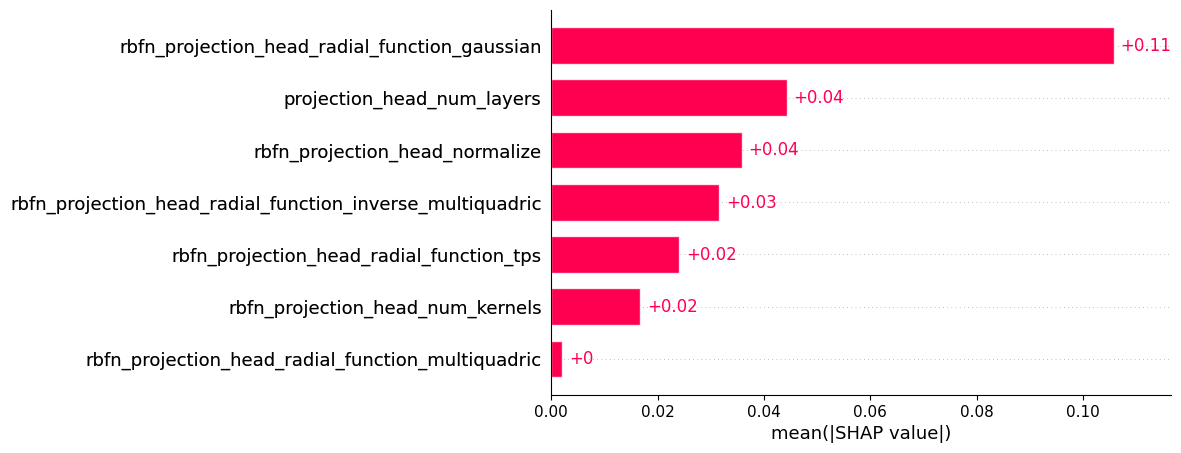

In [47]:
shap.plots.bar(shap_values)

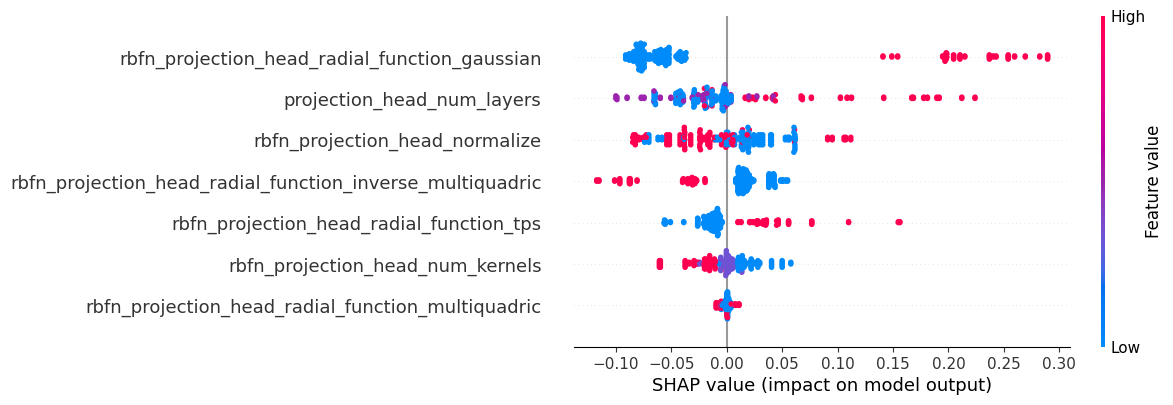

In [48]:
shap.plots.beeswarm(shap_values)